In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os

# Cấu hình hiển thị
%matplotlib inline

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv"
MODEL_FILE = "../../model/rf_model.pkl"

TARGET_COL = "Gold"
SHIFT_STEPS = 1  # Dự báo giờ tiếp theo

print("✅ Đã import Random Forest thành công!")

✅ Đã import Random Forest thành công!


In [3]:
# 1. Đọc dữ liệu
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    
    # Bỏ cột Datetime
    if 'Datetime' in df.columns:
        df = df.drop(columns=['Datetime'])

    # 2. Tạo cột Target (Giá tương lai)
    df['Target'] = df[TARGET_COL].shift(-SHIFT_STEPS)

    # Xóa dòng cuối bị NaN
    df.dropna(inplace=True)
    
    print(f"📂 Dữ liệu sẵn sàng cho Random Forest: {df.shape}")

📂 Dữ liệu sẵn sàng cho Random Forest: (7636, 12)


In [4]:
# 1. Tách Feature (X) và Target (y)
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Chia theo thời gian
split_idx = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")

📊 Train set: (6108, 11)
📊 Val set:   (1528, 11)


In [5]:
print("🚀 Bắt đầu Training Random Forest...")

# Khởi tạo mô hình
# n_estimators=100: Trồng 100 cây (càng nhiều càng mượt nhưng chạy lâu hơn)
# n_jobs=-1: Dùng toàn bộ nhân CPU (chạy cho nhanh)
# random_state=42: Để kết quả cố định mỗi lần chạy
model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,       # Giới hạn độ sâu để tránh học vẹt
    min_samples_leaf=2, # Mỗi lá phải có ít nhất 2 mẫu
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Huấn luyện
model.fit(X_train, y_train)

print("✅ Training hoàn tất!")

# Lưu model
if not os.path.exists("model"):
    os.makedirs("model")
joblib.dump(model, MODEL_FILE)
print(f"💾 Đã lưu model tại {MODEL_FILE}")

🚀 Bắt đầu Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    2.6s


✅ Training hoàn tất!
💾 Đã lưu model tại ../../model/rf_model.pkl


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.4s finished


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished


📉 Kết quả đánh giá Random Forest:
   - RMSE: 0.13912
   - MAE:  0.11474


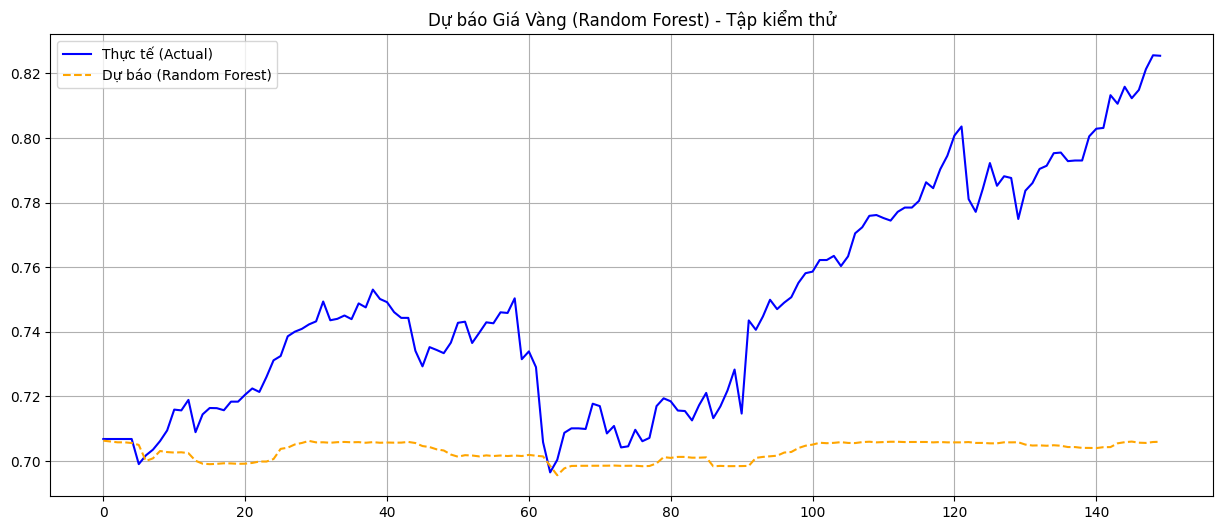

In [6]:
# 1. Dự báo
y_pred = model.predict(X_val)

# 2. Tính sai số
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"📉 Kết quả đánh giá Random Forest:")
print(f"   - RMSE: {rmse:.5f}")
print(f"   - MAE:  {mae:.5f}")

# 3. Vẽ biểu đồ so sánh (Zoom 150 điểm đầu)
plt.figure(figsize=(15, 6))
plt.plot(y_val.values[:150], label='Thực tế (Actual)', color='blue')
plt.plot(y_pred[:150], label='Dự báo (Random Forest)', color='orange', linestyle='--')
plt.title('Dự báo Giá Vàng (Random Forest) - Tập kiểm thử')
plt.legend()
plt.grid(True)
plt.show()

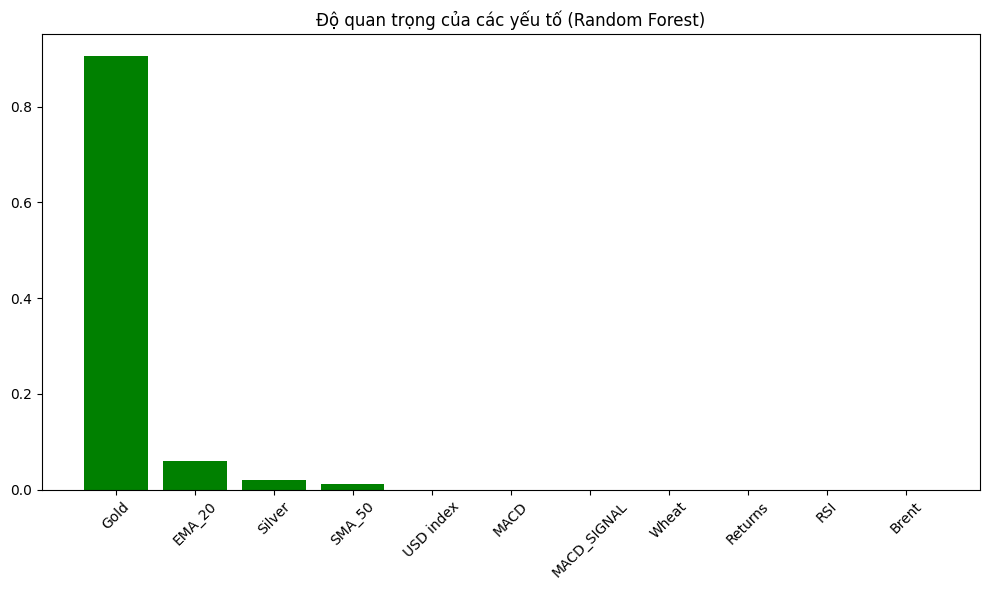

In [7]:
# Lấy độ quan trọng của các đặc trưng
importances = model.feature_importances_
indices = np.argsort(importances)[::-1] # Sắp xếp giảm dần

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.title("Độ quan trọng của các yếu tố (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color="green")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()